# **1. Setup & Libraries**

In [7]:
!pip install matplotlib-scalebar
!pip install contextily

# For post-hoc seasonal tests
!pip install scikit-posthocs

!pip install pymannkendall


In [8]:
import os
import glob
import calendar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.ticker import ScalarFormatter
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns
import geopandas as gpd

from scipy.stats import mannwhitneyu, kruskal, wilcoxon
import pymannkendall as mk
import scikit_posthocs as sp


# **2. Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Rainfall/Data/Final processed 3-hourly rainfall data.csv'
df_rain = pd.read_csv(file_path)
df_rain

,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116614,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 09:00:00,2023,7,31,9,Monsoon,26.0,1016.0,1.0,10.0,73.0,0.0
2116615,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 12:00:00,2023,7,31,12,Monsoon,26.0,1016.0,0.0,0.0,82.0,0.0
2116616,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 15:00:00,2023,7,31,15,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0
2116617,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 18:00:00,2023,7,31,18,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0


In [ ]:
# REMOVE THE LATE STATION (Example ID: 10325)
# Replace 10325 with the actual ID of the 2008 station
stations_to_drop = [11921]
df_rain = df_rain[~df_rain["StationID"].isin(stations_to_drop)].reset_index(drop=True)
df_rain


,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2069862,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 09:00:00,2023,7,31,9,Monsoon,26.0,1016.0,1.0,10.0,73.0,0.0
2069863,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 12:00:00,2023,7,31,12,Monsoon,26.0,1016.0,0.0,0.0,82.0,0.0
2069864,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 15:00:00,2023,7,31,15,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0
2069865,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 18:00:00,2023,7,31,18,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0


# **3. Basic checks**

In [ ]:
df_rain.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2069867 entries, 0 to 2069866
Data columns (total 18 columns):
 #   Column                Dtype  
---  ------                -----  
 0   StationID             int64  
 1   StationName           object 
 2   Latitude              float64
 3   Longitude             float64
 4   Primary_Region        object 
 5   Secondary_Region      object 
 6   Datetime              object 
 7   Year                  int64  
 8   Month                 int64  
 9   Day                   int64  
 10  Time                  int64  
 11  Season                object 
 12  DewPointTemperature   float64
 13  StationLevelPressure  float64
 14  SP                    float64
 15  DR                    float64
 16  Humidity              float64
 17  Rainfall              float64
dtypes: float64(8), int64(5), object(5)
memory usage: 284.3+ MB


In [ ]:
df_rain.describe()


,StationID,Latitude,Longitude,Year,Month,Day,Time,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
count,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06,2.069867e+06
mean,1.590622e+04,2.332243e+01,9.042684e+01,2.013025e+03,6.517799e+00,1.572708e+01,1.049884e+01,2.158189e+01,1.006446e+03,1.490370e+00,9.316562e+00,8.056917e+01,7.877763e-01
std,1.086843e+04,1.199083e+00,1.120197e+00,6.022836e+00,3.448572e+00,8.798788e+00,6.873358e+00,5.190200e+00,1.518150e+01,2.136396e+00,1.119727e+01,1.673008e+01,4.271327e+00
min,1.012000e+04,2.086670e+01,8.868330e+01,2.003000e+03,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,1.111100e+04,2.248330e+01,8.936670e+01,2.008000e+03,4.000000e+00,8.000000e+00,3.000000e+00,1.800000e+01,1.002200e+03,0.000000e+00,0.000000e+00,7.100000e+01,0.000000e+00
50%,1.170400e+04,2.316670e+01,9.033330e+01,2.013000e+03,7.000000e+00,1.600000e+01,9.000000e+00,2.400000e+01,1.006900e+03,0.000000e+00,0.000000e+00,8.600000e+01,0.000000e+00
75%,1.192900e+04,2.425000e+01,9.143330e+01,2.018000e+03,1.000000e+01,2.300000e+01,1.500000e+01,2.600000e+01,1.011300e+03,2.000000e+00,1.800000e+01,9.400000e+01,0.000000e+00
max,4.197700e+04,2.578330e+01,9.230000e+01,2.023000e+03,1.200000e+01,3.100000e+01,2.100000e+01,3.600000e+01,4.012300e+03,9.000000e+01,1.800000e+02,1.000000e+02,9.990000e+01


In [ ]:
df_rain["Datetime"] = pd.to_datetime(df_rain["Datetime"])
df_rain = df_rain.sort_values("Datetime")
print(df_rain["Datetime"].min(), " → ", df_rain["Datetime"].max())


2003-01-01 00:00:00  →  2023-12-31 21:00:00


In [ ]:
print("Stations:", df_rain["StationID"].nunique())
df_rain.groupby("StationID")["Rainfall"].count().describe()


Stations: 34


,Rainfall
count,34.000000
mean,60878.441176
std,1050.853829
min,58424.000000
25%,61273.000000
50%,61360.000000
75%,61360.000000
max,61360.000000


In [ ]:
df_rain.isna().mean()


,0
StationID,0.0
StationName,0.0
Latitude,0.0
Longitude,0.0
Primary_Region,0.0
Secondary_Region,0.0
Datetime,0.0
Year,0.0
Month,0.0
Day,0.0


In [ ]:
df_rain["Rainfall"].isna().mean()


np.float64(0.0)

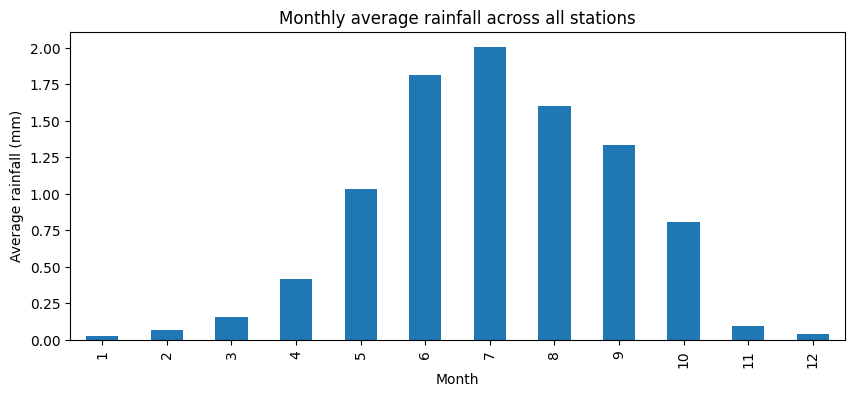

In [ ]:
monthly = df_rain.groupby("Month")["Rainfall"].mean()

monthly.plot(kind="bar", figsize=(10,4))
plt.ylabel("Average rainfall (mm)")
plt.title("Monthly average rainfall across all stations")
plt.show()


In [ ]:
threshold_95 = df_rain["Rainfall"].quantile(0.95)
threshold_99 = df_rain["Rainfall"].quantile(0.99)

threshold_95, threshold_99


(np.float64(3.4), np.float64(21.0))

In [ ]:
gaps = (
    df_rain.sort_values("Datetime")
           .groupby("StationID")["Datetime"]
           .diff()
)

gaps_in_hours = gaps.dt.total_seconds() / 3600
gaps_in_hours.value_counts().head(10)


,count
Datetime,
3.0,2069584
6.0,237
24.0,8
7347.0,1
8763.0,1
723.0,1
747.0,1


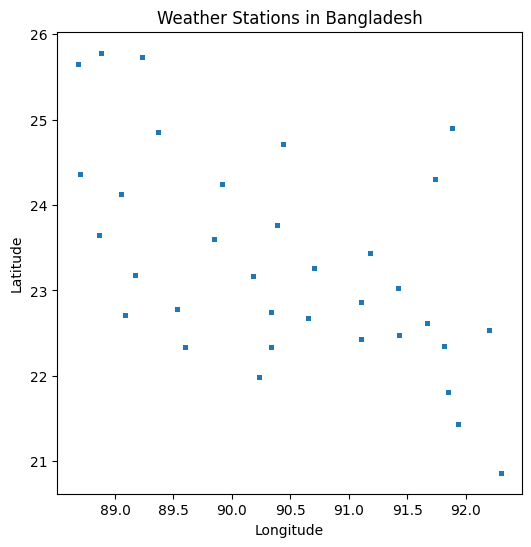

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df_rain["Longitude"], df_rain["Latitude"], s=5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Weather Stations in Bangladesh")
plt.show()


In [ ]:
station_mean = df_rain.groupby("StationID")["Rainfall"].mean()

station_mean.describe(), station_mean.sort_values().head(), station_mean.sort_values().tail()


(count    34.000000
 mean      0.789961
 std       0.257914
 min       0.434223
 25%       0.607140
 50%       0.697358
 75%       0.960748
 max       1.377476
 Name: Rainfall, dtype: float64,
 StationID
 10320    0.434223
 10910    0.473204
 41926    0.477689
 11505    0.537464
 10408    0.554707
 Name: Rainfall, dtype: float64,
 StationID
 11814    1.142311
 11927    1.177409
 11916    1.213818
 11929    1.374957
 10705    1.377476
 Name: Rainfall, dtype: float64)

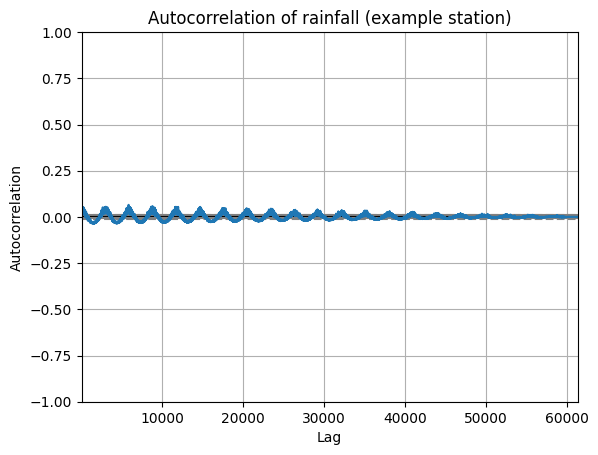

In [ ]:
example_station = df_rain["StationID"].iloc[0]
series = df_rain[df_rain["StationID"] == example_station]["Rainfall"]

from pandas.plotting import autocorrelation_plot
autocorrelation_plot(series)
plt.title("Autocorrelation of rainfall (example station)")
plt.show()


In [ ]:
import numpy as np

is_heavy = df_rain["Rainfall"] >= 20  # example heavy threshold
run_length = np.diff(np.where(np.concatenate(([is_heavy.iloc[0]],
      is_heavy.to_numpy()[:-1] != is_heavy.to_numpy()[1:], [True]))))[::2]

run_length[:20]


array([[   2,  402,    1, ...,   27,    1, 6069]])

In [ ]:
df_rain.groupby("Season")["Rainfall"].quantile(0.99)


,Rainfall
Season,
Monsoon,32.0
Post-Monsoon,13.8
Pre-Monsoon,17.0
Winter,0.4


In [ ]:
df_rain["Rainfall"].sort_values(ascending=False).head(10)


,Rainfall
1038533,99.9
1833540,99.8
185574,99.8
1833093,99.4
1833092,99.4
1237462,99.2
1041784,99.2
903475,99.0
1467547,99.0
729215,99.0


# **Spatial distribution of the 34 meteorological stations across major climatic regions of Bangladesh**

🔍 Scanning /content/drive/MyDrive/Dry Thunderstrom...
✅ Fallback using: bgd_admin2.shp


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'bgd_admin_boundaries.shp': 'bgd_adminpoints' (default), 'bgd_admin2', 'bgd_admin0', 'bgd_admincapitals', 'bgd_admin1', 'bgd_admin3', 'bgd_adminlines'. Specify layer parameter to avoid this warning.
  result = read_func(


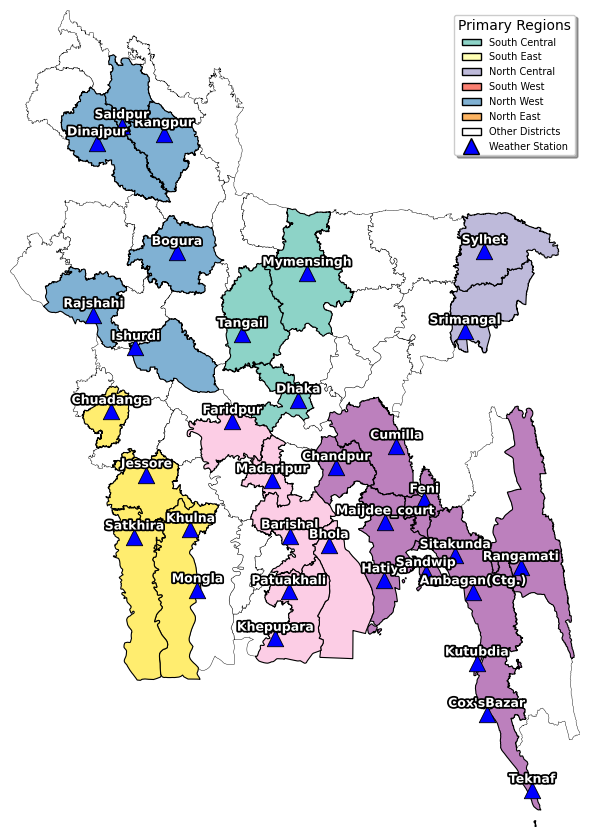

In [ ]:
import os
import glob
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patheffects as pe
from google.colab import drive


# --- 2. INTELLIGENT SHAPE FINDER ---
search_folder = "/content/drive/MyDrive/Dry Thunderstrom"
print(f"🔍 Scanning {search_folder}...")

shapefiles = glob.glob(os.path.join(search_folder, "**", "*.shp"), recursive=True)
target_map_path = None

for file_path in shapefiles:
    filename = os.path.basename(file_path).lower()
    if 'adm2' in filename:
        try:
            test_load = gpd.read_file(file_path, rows=1)
            geom_type = test_load.geometry.iloc[0].geom_type
            if geom_type in ['Polygon', 'MultiPolygon']:
                target_map_path = file_path
                print(f"✅ Found Correct Polygon File: {filename}")
                break
        except:
            continue

if not target_map_path:
    for file_path in shapefiles:
        try:
            test_load = gpd.read_file(file_path, rows=1)
            if test_load.geometry.iloc[0].geom_type in ['Polygon', 'MultiPolygon']:
                target_map_path = file_path
                print(f"✅ Fallback using: {os.path.basename(file_path)}")
                break
        except:
            continue

if not target_map_path:
    raise FileNotFoundError("❌ No valid Map Shapefile found!")

bd_districts = gpd.read_file(target_map_path)

# --- 3. PREPARE DATA ---
try:
    cols = ['StationName', 'Latitude', 'Longitude', 'Primary_Region']
    unique_stations = df_rain[cols].drop_duplicates(subset='StationName')
except NameError:
    print("⚠️ 'df_rain' not found. Using DUMMY data.")
    import pandas as pd
    unique_stations = pd.DataFrame({
        'Station_Name': ['Dhaka', 'Chittagong', 'Sylhet', 'Rajshahi', 'Khulna'],
        'Latitude': [23.81, 22.35, 24.89, 24.36, 22.84],
        'Longitude': [90.41, 91.78, 91.86, 88.60, 89.54],
        'Primary_Region': ['Central', 'South East', 'North East', 'North West', 'South West']
    })

stations_gdf = gpd.GeoDataFrame(
    unique_stations,
    geometry=gpd.points_from_xy(unique_stations.Longitude, unique_stations.Latitude),
    crs="EPSG:4326"
)

# --- 4. COLOR LOGIC ---
bd_proj = bd_districts.to_crs(epsg=32646)
stations_proj = stations_gdf.to_crs(epsg=32646)

possible_cols = ['ADM2_EN', 'ADM2_VI', 'dist_name', 'NAME_2', 'name']
dist_col = next((c for c in possible_cols if c in bd_proj.columns), bd_proj.columns[0])

joined = gpd.sjoin(stations_proj, bd_proj, how="left", predicate="within")
district_region_map = joined.set_index(dist_col)['Primary_Region'].to_dict()
bd_proj['assigned_region'] = bd_proj[dist_col].map(district_region_map)

background_layer = bd_proj[bd_proj['assigned_region'].isna()]
study_layer = bd_proj[bd_proj['assigned_region'].notna()]

# --- 5. PLOTTING ---
fig, ax = plt.subplots(figsize=(6, 10))

# Background Colors
ax.set_facecolor('#d4f1f9')
background_layer.plot(ax=ax, color='white', edgecolor='black', linewidth=0.3)

# Study Regions
study_layer.plot(ax=ax, column='assigned_region', cmap='Set3', edgecolor='black', linewidth=0.8)

# Stations (Blue Triangles)
stations_proj.plot(ax=ax, color='blue', marker='^', markersize=140,
                   edgecolor='black', linewidth=0.6, zorder=5)

# Reduce Whitespace
minx, miny, maxx, maxy = bd_proj.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# --- 6. LABELS ---
for x, y, label in zip(stations_proj.geometry.x, stations_proj.geometry.y, stations_proj['StationName']):
    txt = ax.text(x, y + 6000, label, fontsize=9, fontweight='bold',
                  ha='center', zorder=6, color='white')
    txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground='black')])

# Legend
unique_regions = study_layer['assigned_region'].unique()
cmap = plt.get_cmap('Set3')
legend_patches = []
for i, region in enumerate(unique_regions):
    color = cmap(i % 12)
    legend_patches.append(mpatches.Patch(facecolor=color, edgecolor='black', label=region))

legend_patches.append(mpatches.Patch(facecolor='white', edgecolor='black', label='Other Districts'))
legend_patches.append(plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='blue',
                                 markeredgecolor='black', markersize=12, label='Weather Station'))

# --- CHANGED: Legend location moved to 'upper right' ---
ax.legend(handles=legend_patches, loc='upper right', title="Primary Regions", fontsize=7, frameon=True, shadow=True)

# Scale & Arrow
# ax.add_artist(ScaleBar(1, "m", location="lower right", box_alpha=0.8))
# x_arrow, y_arrow = ax.get_xlim()[1], ax.get_ylim()[1]
# ax.text(x_arrow - 30000, y_arrow - 20000, 'N', fontsize=24, weight='bold', ha='center')
# ax.arrow(x_arrow - 30000, y_arrow - 55000, 0, 30000, fc='k', ec='k', width=2000, head_width=7000)

ax.set_axis_off()
#plt.title("Study Area by Region", fontsize=18, weight='bold', pad=20)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Rainfall/EDA/StudyAreaFinal_Blue.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()

# **Frequency distribution of observed hourly rainfall**

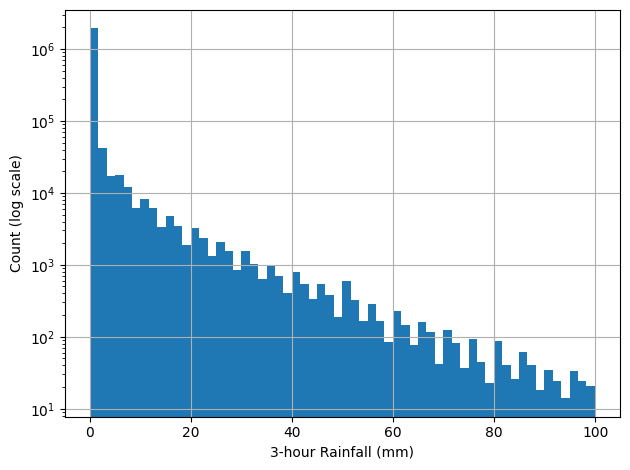

In [ ]:
import matplotlib.pyplot as plt

df_rain["Rainfall"].hist(bins=60, log=True)
plt.xlabel("3-hour Rainfall (mm)")
plt.ylabel("Count (log scale)")
#plt.title("Distribution of 3-hourly rainfall")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Rainfall/EDA/rainfall_distribution.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()


# **Observed annual total rainfall from 34 stations (2003–2023)**

✅ Success: Figure saved to /content/drive/MyDrive/Rainfall/EDA/annual_rainfall_trend.pdf


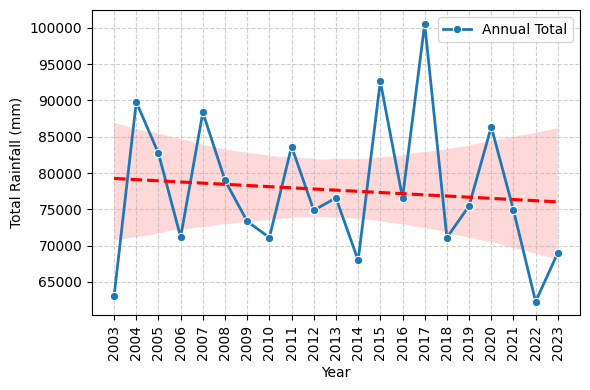

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Directory
SAVE_DIR = "/content/drive/MyDrive/Rainfall/EDA/"
os.makedirs(SAVE_DIR, exist_ok=True)

def plot_annual_trend_only(df):
    # Ensure Datetime format and Year extraction
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df['Year'] = df['Datetime'].dt.year

    # Aggregate annual total rainfall
    annual_rain = df.groupby('Year')['Rainfall'].sum().reset_index()

    # Create Figure
    plt.figure(figsize=(6, 4))

    # Annual Rainfall Line with Points
    sns.lineplot(data=annual_rain, x='Year', y='Rainfall', marker='o',
                 color='#1f77b4', linewidth=2, label='Annual Total')

    # Linear Regression Trend Line
    sns.regplot(data=annual_rain, x='Year', y='Rainfall', scatter=False,
                color='red', line_kws={"linestyle":"--", "label": "Trend Line"})

    years = annual_rain['Year'].unique()
    plt.xticks(ticks=years, labels=years, rotation=90)

    plt.xlabel('Year', fontsize=10)
    plt.ylabel('Total Rainfall (mm)', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='best', frameon=True)

    # Adjust layout to prevent clipping
    plt.tight_layout()

    # Save the figure
    output_path = os.path.join(SAVE_DIR, "annual_rainfall_trend.pdf")
    plt.savefig(output_path, dpi=300)

    print(f"✅ Success: Figure saved to {output_path}")

# Execute
plot_annual_trend_only(df_rain)

#**Spatial distribution of annual rainfall trends and primary climatic regions in Bangladesh (2003–2023); blue indicates increasing trends and red indicates decreasing trends.**

🔍 Scanning /content/drive/MyDrive/Dry Thunderstrom...


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'bgd_admin_boundaries.shp': 'bgd_adminpoints' (default), 'bgd_admin2', 'bgd_admin0', 'bgd_admincapitals', 'bgd_admin1', 'bgd_admin3', 'bgd_adminlines'. Specify layer parameter to avoid this warning.
  result = read_func(


✅ Fallback using: bgd_admin2.shp
...Calculating annual rainfall trends (Directional Slopes)...


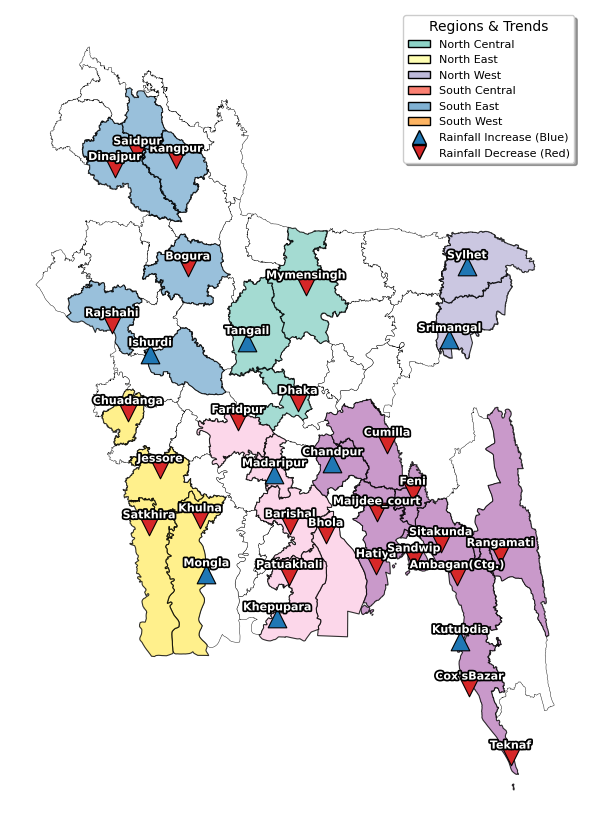

In [ ]:
import os
import glob
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib_scalebar.scalebar import ScaleBar
import pymannkendall as mk
import numpy as np

# --- 1. TREND CALCULATION FUNCTION ---
def calculate_rainfall_trends_from_df(target_df):
    print(f"...Calculating annual rainfall trends (Directional Slopes)...")
    station_results = []
    unique_stations = target_df['StationName'].unique()

    for station in unique_stations:
        station_data = target_df[target_df['StationName'] == station]
        start_year, end_year = station_data['Year'].min(), station_data['Year'].max()
        all_years = pd.DataFrame({'Year': range(start_year, end_year + 1)})

        yearly_totals = station_data.groupby('Year')['Rainfall'].sum().reset_index(name='Total_Rain')
        merged = pd.merge(all_years, yearly_totals, on='Year', how='left').fillna(0)

        try:
            result = mk.original_test(merged['Total_Rain'])
            slope = result.slope

            # --- COLOR LOGIC: Blue for Increase, Red for Decrease ---
            if slope > 0:
                status, color, marker = "Increase", "#1f77b4", '^'  # Blue
            elif slope < 0:
                status, color, marker = "Decrease", "#d62728", 'v'  # Red
            else:
                status, color, marker = "No Trend", "lightgrey", 'o'

            station_results.append({
                'StationName': station,
                'Latitude': station_data['Latitude'].iloc[0],
                'Longitude': station_data['Longitude'].iloc[0],
                'Primary_Region': station_data['Primary_Region'].iloc[0],
                'Slope': slope,
                'Status': status,
                'Trend_Color': color,
                'Marker': marker
            })
        except Exception as e:
            print(f"❌ Error at station {station}: {e}")

    return pd.DataFrame(station_results)

# --- 2. INTELLIGENT SHAPE FINDER ---
search_folder = "/content/drive/MyDrive/Dry Thunderstrom"
print(f"🔍 Scanning {search_folder}...")

shapefiles = glob.glob(os.path.join(search_folder, "**", "*.shp"), recursive=True)
target_map_path = None

for file_path in shapefiles:
    filename = os.path.basename(file_path).lower()
    if 'adm2' in filename:
        try:
            test_load = gpd.read_file(file_path, rows=1)
            geom_type = test_load.geometry.iloc[0].geom_type
            if geom_type in ['Polygon', 'MultiPolygon']:
                target_map_path = file_path
                print(f"✅ Found Correct Polygon File: {filename}")
                break
        except:
            continue

if not target_map_path:
    for file_path in shapefiles:
        try:
            test_load = gpd.read_file(file_path, rows=1)
            if test_load.geometry.iloc[0].geom_type in ['Polygon', 'MultiPolygon']:
                target_map_path = file_path
                print(f"✅ Fallback using: {os.path.basename(file_path)}")
                break
        except:
            continue

if not target_map_path:
    raise FileNotFoundError("❌ No valid Map Shapefile found!")

bd_districts = gpd.read_file(target_map_path)

# --- 3. EXECUTE TRENDS AND GEOPROJECT ---
results_df = calculate_rainfall_trends_from_df(df_rain)
stations_gdf = gpd.GeoDataFrame(
    results_df,
    geometry=gpd.points_from_xy(results_df.Longitude, results_df.Latitude),
    crs="EPSG:4326"
)

bd_proj = bd_districts.to_crs(epsg=32646)
stations_proj = stations_gdf.to_crs(epsg=32646)

# --- 4. REGIONAL MAPPING LOGIC ---
possible_cols = ['ADM2_EN', 'ADM2_VI', 'dist_name', 'NAME_2', 'name']
dist_col = next((c for c in possible_cols if c in bd_proj.columns), bd_proj.columns[0])

joined = gpd.sjoin(stations_proj, bd_proj, how="left", predicate="within")
district_region_map = joined.set_index(dist_col)['Primary_Region'].to_dict()
bd_proj['assigned_region'] = bd_proj[dist_col].map(district_region_map)

background_layer = bd_proj[bd_proj['assigned_region'].isna()]
study_layer = bd_proj[bd_proj['assigned_region'].notna()]

# --- 5. PLOTTING ---
fig, ax = plt.subplots(figsize=(6, 10))
ax.set_facecolor('#d4f1f9') # Ocean color

# Background Districts (White)
background_layer.plot(ax=ax, color='white', edgecolor='black', linewidth=0.3)

# Study Regions (Set3 Colormap)
study_layer.plot(ax=ax, column='assigned_region', cmap='Set3', edgecolor='black', linewidth=0.8, alpha=0.8)

# Plot Increase Trend (Blue Triangles)
stations_proj[stations_proj['Status'] == "Increase"].plot(
    ax=ax, color='#1f77b4', marker='^', markersize=180, edgecolor='black', linewidth=0.8, zorder=5
)

# Plot Decrease Trend (Red Triangles)
stations_proj[stations_proj['Status'] == "Decrease"].plot(
    ax=ax, color='#d62728', marker='v', markersize=180, edgecolor='black', linewidth=0.8, zorder=6
)

# --- 6. LABELS & LEGEND ---
for x, y, label in zip(stations_proj.geometry.x, stations_proj.geometry.y, stations_proj['StationName']):
    txt = ax.text(x, y + 7000, label, fontsize=8, fontweight='bold', ha='center', zorder=7, color='white')
    txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground='black')])

# Legend Construction
unique_regions = sorted(study_layer['assigned_region'].unique())
cmap = plt.get_cmap('Set3')
legend_patches = []
for i, region in enumerate(unique_regions):
    legend_patches.append(mpatches.Patch(facecolor=cmap(i % 12), edgecolor='black', label=region))

legend_patches.append(plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='#1f77b4',
                                 markeredgecolor='black', markersize=10, label='Rainfall Increase (Blue)'))
legend_patches.append(plt.Line2D([0], [0], marker='v', color='w', markerfacecolor='#d62728',
                                 markeredgecolor='black', markersize=10, label='Rainfall Decrease (Red)'))

ax.legend(handles=legend_patches, loc='upper right', title="Regions & Trends", fontsize=8, frameon=True, shadow=True)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Rainfall/EDA/Rainfall_Regional_Trend_Map.pdf", dpi=300, bbox_inches='tight')
plt.show()

# **Annual rainfall variations (2003–2023) by (a) season, (b) primary, and (c) secondary region**

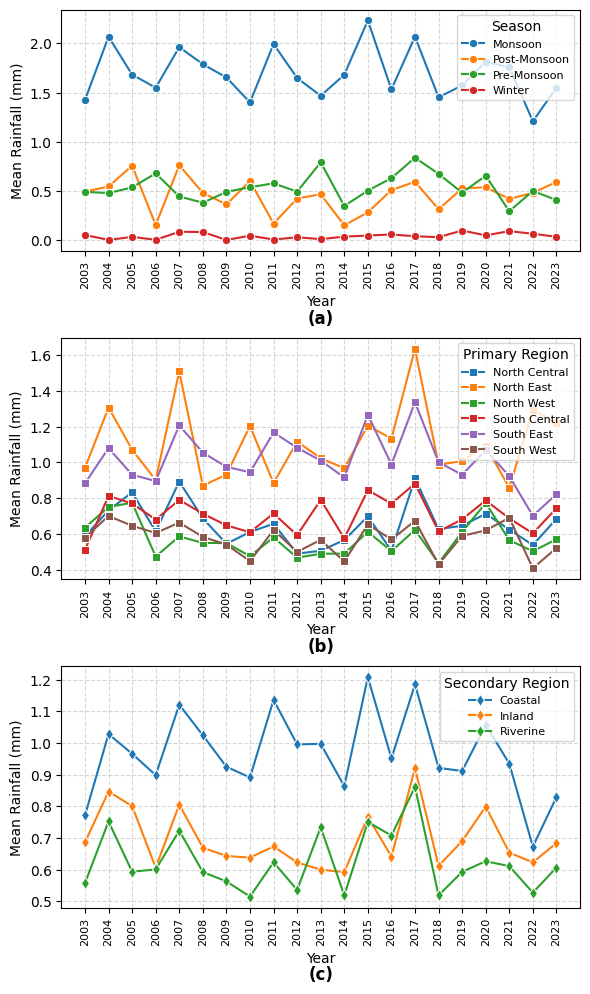

✅ Success: Temporal trends for ['Coastal' 'Riverine' 'Inland'] zones saved.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Setup Directory
SAVE_DIR = "/content/drive/MyDrive/Rainfall/EDA/"
os.makedirs(SAVE_DIR, exist_ok=True)

def plot_rainfall_temporal_trends_final(df):
    # Ensure Datetime and Year formatting
    if 'Year' not in df.columns:
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df['Year'] = df['Datetime'].dt.year

    # Filter for the specific study period 2003-2023
    df = df[(df['Year'] >= 2003) & (df['Year'] <= 2023)]
    target_years = np.arange(2003, 2024)

    # Create Figure (Single Column Layout)
    fig, axes = plt.subplots(3, 1, figsize=(6, 10))

    # Helper function for consistent formatting
    def apply_style(ax, label):
        ax.set_ylabel('Mean Rainfall (mm)')
        ax.set_xlabel('Year')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xticks(target_years)
        ax.set_xticklabels(target_years, rotation=90, fontsize=8)
        ax.text(0.5, -0.3, label, transform=ax.transAxes, size=12, ha="center", weight='bold')

    # --- Subplot 1: Trends by Season ---
    season_trend = df.groupby(['Year', 'Season'])['Rainfall'].mean().reset_index()
    sns.lineplot(data=season_trend, x='Year', y='Rainfall', hue='Season', marker='o', ax=axes[0])
    axes[0].legend(title='Season', loc='upper right', fontsize=8)
    apply_style(axes[0], "(a)")

    # --- Subplot 2: Trends by Primary Region ---
    primary_trend = df.groupby(['Year', 'Primary_Region'])['Rainfall'].mean().reset_index()
    sns.lineplot(data=primary_trend, x='Year', y='Rainfall', hue='Primary_Region', marker='s', ax=axes[1])
    axes[1].legend(title='Primary Region', loc='upper right', fontsize=8)
    apply_style(axes[1], "(b)")

    # --- Subplot 3: Trends by Secondary Region (Inland, Coastal, Riverine) ---
    # No more "Top 5" filter - plotting all three environmental zones
    secondary_trend = df.groupby(['Year', 'Secondary_Region'])['Rainfall'].mean().reset_index()
    sns.lineplot(data=secondary_trend, x='Year', y='Rainfall', hue='Secondary_Region', marker='d', ax=axes[2])
    axes[2].legend(title='Secondary Region', loc='upper right', fontsize=8)
    apply_style(axes[2], "(c)")

    plt.tight_layout()

    output_path = os.path.join(SAVE_DIR, "rainfall_temporal_trends_fixed.pdf")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Success: Temporal trends for {df['Secondary_Region'].unique()} zones saved.")

# Execute
plot_rainfall_temporal_trends_final(df_rain)

# **Climatological rainfall cycles in Bangladesh (2003--2023) based on mean precipitation (mm) aggregated by (a) month, (b) day of the month, and (c) hour of the day.**

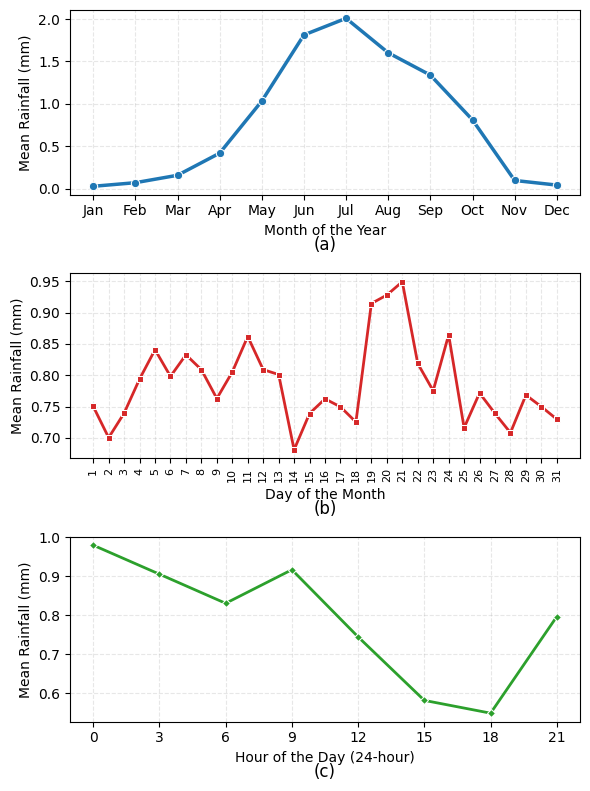

✅ Success: Single-line aggregate plots saved to /content/drive/MyDrive/Rainfall/EDA/rainfall_climatological_averages.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Setup Directory
SAVE_DIR = "/content/drive/MyDrive/Rainfall/EDA/"
os.makedirs(SAVE_DIR, exist_ok=True)

def plot_climatological_cycles(df):
    # 1. Ensure Time Components and Filtering
    if 'Datetime' in df.columns:
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df['Year'] = df['Datetime'].dt.year
        df['Month'] = df['Datetime'].dt.month
        df['Day'] = df['Datetime'].dt.day
        df['Hour'] = df['Datetime'].dt.hour

    # Filter for the study period 2003-2023
    df_filtered = df[(df['Year'] >= 2003) & (df['Year'] <= 2023)].copy()

    # Create Figure (Single Column Layout)
    fig, axes = plt.subplots(3, 1, figsize=(6, 8))

    # Style helper
    def apply_style(ax, label, xlabel):
        ax.set_ylabel('Mean Rainfall (mm)', fontsize=10)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.text(0.5, -0.3, label, transform=ax.transAxes, size=12, ha="center")

    # --- (a) X-axis: Month (Average across 2003-2023) ---
    month_avg = df_filtered.groupby('Month')['Rainfall'].mean().reset_index()
    sns.lineplot(data=month_avg, x='Month', y='Rainfall', color='#1f77b4', marker='o', linewidth=2.5, ax=axes[0])
    axes[0].set_xticks(range(1, 13))
    axes[1].tick_params(axis='x', rotation=90, labelsize=8)
    axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    apply_style(axes[0], "(a)", "Month of the Year")

    # --- (b) X-axis: Day (Average across 2003-2023) ---
    day_avg = df_filtered.groupby('Day')['Rainfall'].mean().reset_index()
    sns.lineplot(data=day_avg, x='Day', y='Rainfall', color='#d62728', marker='s', markersize=4, linewidth=2, ax=axes[1])
    axes[1].set_xticks(range(1, 32))
    axes[1].tick_params(axis='x', rotation=90, labelsize=8)
    apply_style(axes[1], "(b)", "Day of the Month")

    # --- (c) X-axis: Hour (Average across 2003-2023) ---
    hour_avg = df_filtered.groupby('Hour')['Rainfall'].mean().reset_index()
    sns.lineplot(data=hour_avg, x='Hour', y='Rainfall', color='#2ca02c', marker='D', markersize=4, linewidth=2, ax=axes[2])
    axes[2].set_xticks(range(0, 24, 3))
    apply_style(axes[2], "(c)", "Hour of the Day (24-hour)")
    axes[1].tick_params(axis='x', rotation=90, labelsize=8)

    plt.tight_layout()

    output_path = os.path.join(SAVE_DIR, "rainfall_climatological_averages.pdf")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Success: Single-line aggregate plots saved to {output_path}")

# Execute
plot_climatological_cycles(df_rain)

# **Pearson correlation matrix of meteorological variables**

In [ ]:
df_rain.columns

Index(['StationID', 'StationName', 'Latitude', 'Longitude', 'Primary_Region',
       'Secondary_Region', 'Datetime', 'Year', 'Month', 'Day', 'Time',
       'Season', 'DewPointTemperature', 'StationLevelPressure', 'SP', 'DR',
       'Humidity', 'Rainfall', 'Hour'],
      dtype='object')

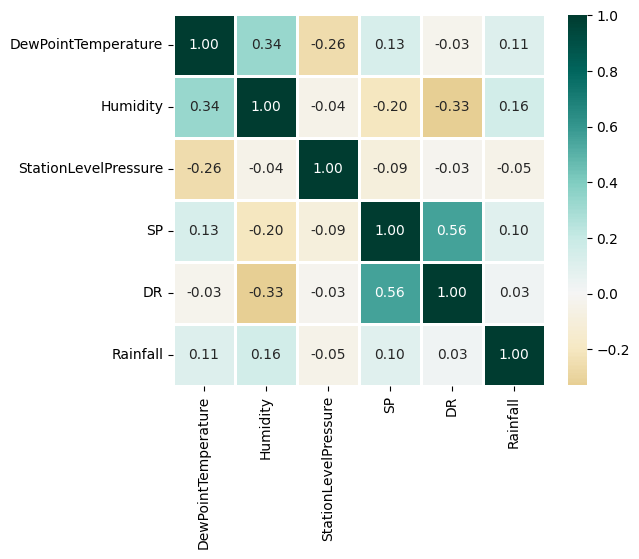

✅ Feature Correlation Heatmap saved to /content/drive/MyDrive/Rainfall/EDA/Feature_Correlation_Heatmap.pdf


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Define variables
met_vars = ['DewPointTemperature', 'Humidity', 'StationLevelPressure', 'SP', 'DR', 'Rainfall']
available_vars = [v for v in met_vars if v in df_rain.columns]

# 2. Correlation Matrix
feature_corr = df_rain[available_vars].corr()

# 3. Plotting
plt.figure(figsize=(6, 8))
sns.heatmap(feature_corr,
            annot=True,
            fmt=".2f",
            cmap='BrBG',
            center=0,
            linewidths=1,
            square=True,
            # REDUCE SIDEBAR: shrink makes it shorter, aspect makes it thinner
            cbar_kws={"shrink": .6, "aspect": 20})

# Save the figure
save_path_met = "/content/drive/MyDrive/Rainfall/EDA/Feature_Correlation_Heatmap.pdf"
plt.savefig(save_path_met, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Feature Correlation Heatmap saved to {save_path_met}")

# **Total rainfall amounts by Season**

/tmp/ipython-input-2047185833.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal_totals, x='Season', y='Rainfall',


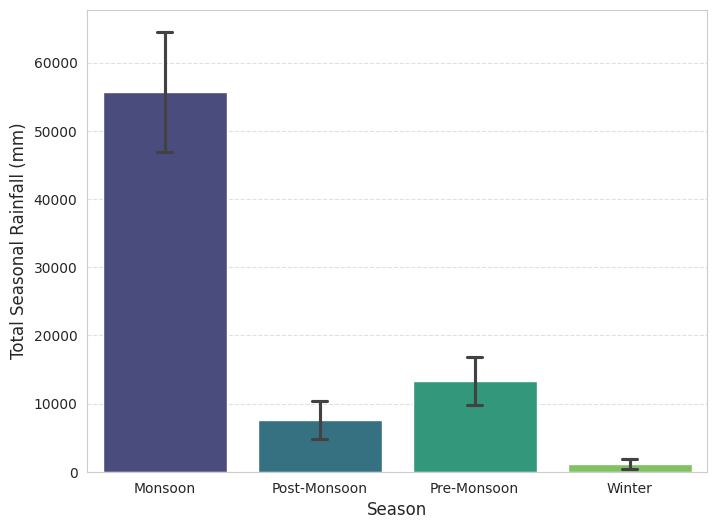

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aggregate total rainfall per season per year
seasonal_totals = df_rain.groupby(['Year', 'Season'])['Rainfall'].sum().reset_index()

# 2. Plotting the average total rainfall for each season
plt.figure(figsize=(8, 6))
sns.barplot(data=seasonal_totals, x='Season', y='Rainfall',
            palette='viridis', errorbar='sd', capsize=.1)

# 3. Aesthetics
#plt.title("Average Annual Rainfall Volume by Season (2003-2023)", fontsize=13, fontweight='bold')
plt.ylabel("Total Seasonal Rainfall (mm)", fontsize=12)
plt.xlabel("Season", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Save
save_path_season = "/content/drive/MyDrive/Rainfall/EDA/Seasonal_Total_Rainfall.pdf"
plt.savefig(save_path_season, dpi=300, bbox_inches='tight')
plt.show()

# **Variations of monthly rainfall amounts (2003-2023)**

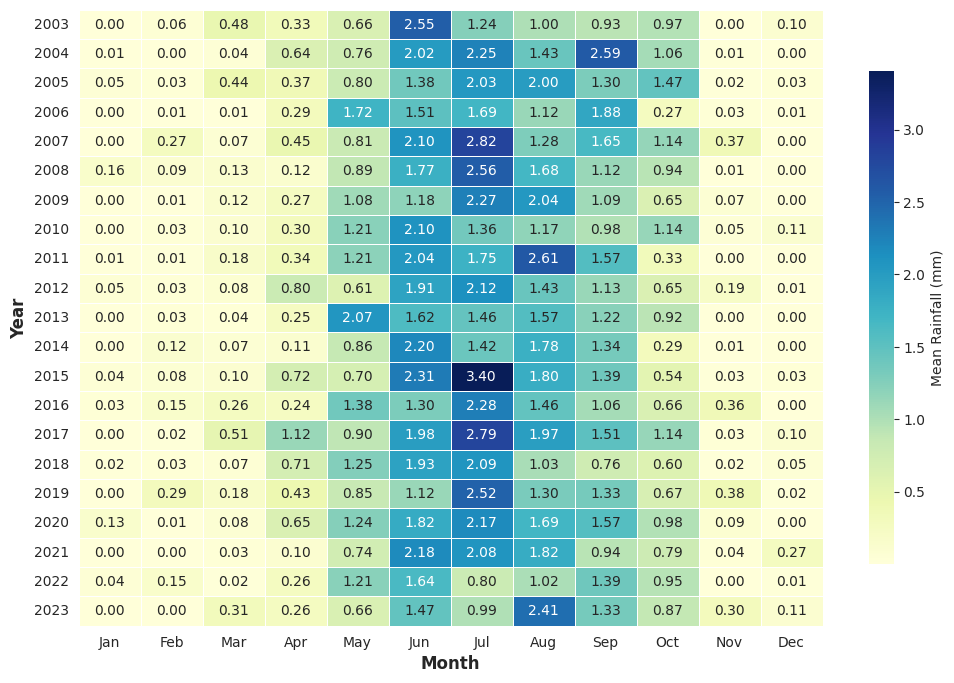

✅ Seasonal Heatmap saved to /content/drive/MyDrive/Rainfall/EDA/Monthly_Rainfall_Heatmap_Years.pdf


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data
# Ensure Datetime is in correct format and extract Year/Month
df_rain['Datetime'] = pd.to_datetime(df_rain['Datetime'])
df_rain['Year'] = df_rain['Datetime'].dt.year
df_rain['Month'] = df_rain['Datetime'].dt.month

# 2. Pivot data to create a matrix: Year vs Month (Average Rainfall)
pivot_df = df_rain.pivot_table(index='Year', columns='Month', values='Rainfall', aggfunc='mean')

# Rename months for the plot
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pivot_df.columns = month_names

# 3. Plotting
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df,
            cmap='YlGnBu',
            annot=True,
            fmt=".2f",
            linewidths=.5,
            cbar_kws={'label': 'Mean Rainfall (mm)', 'shrink': 0.8})

#plt.title("Rainfall Intensity Fingerprint: Monthly Mean per Year (2003-2023)",
          #fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Month", fontsize=12, fontweight='bold')
plt.ylabel("Year", fontsize=12, fontweight='bold')

# Save the figure
save_path_heatmap = "/content/drive/MyDrive/Rainfall/EDA/Monthly_Rainfall_Heatmap_Years.pdf"
plt.savefig(save_path_heatmap, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Seasonal Heatmap saved to {save_path_heatmap}")

# **Hierarchical Clustering of Station-wise Rainfall Correlations (2003–2023)**

<Figure size 1200x1000 with 0 Axes>

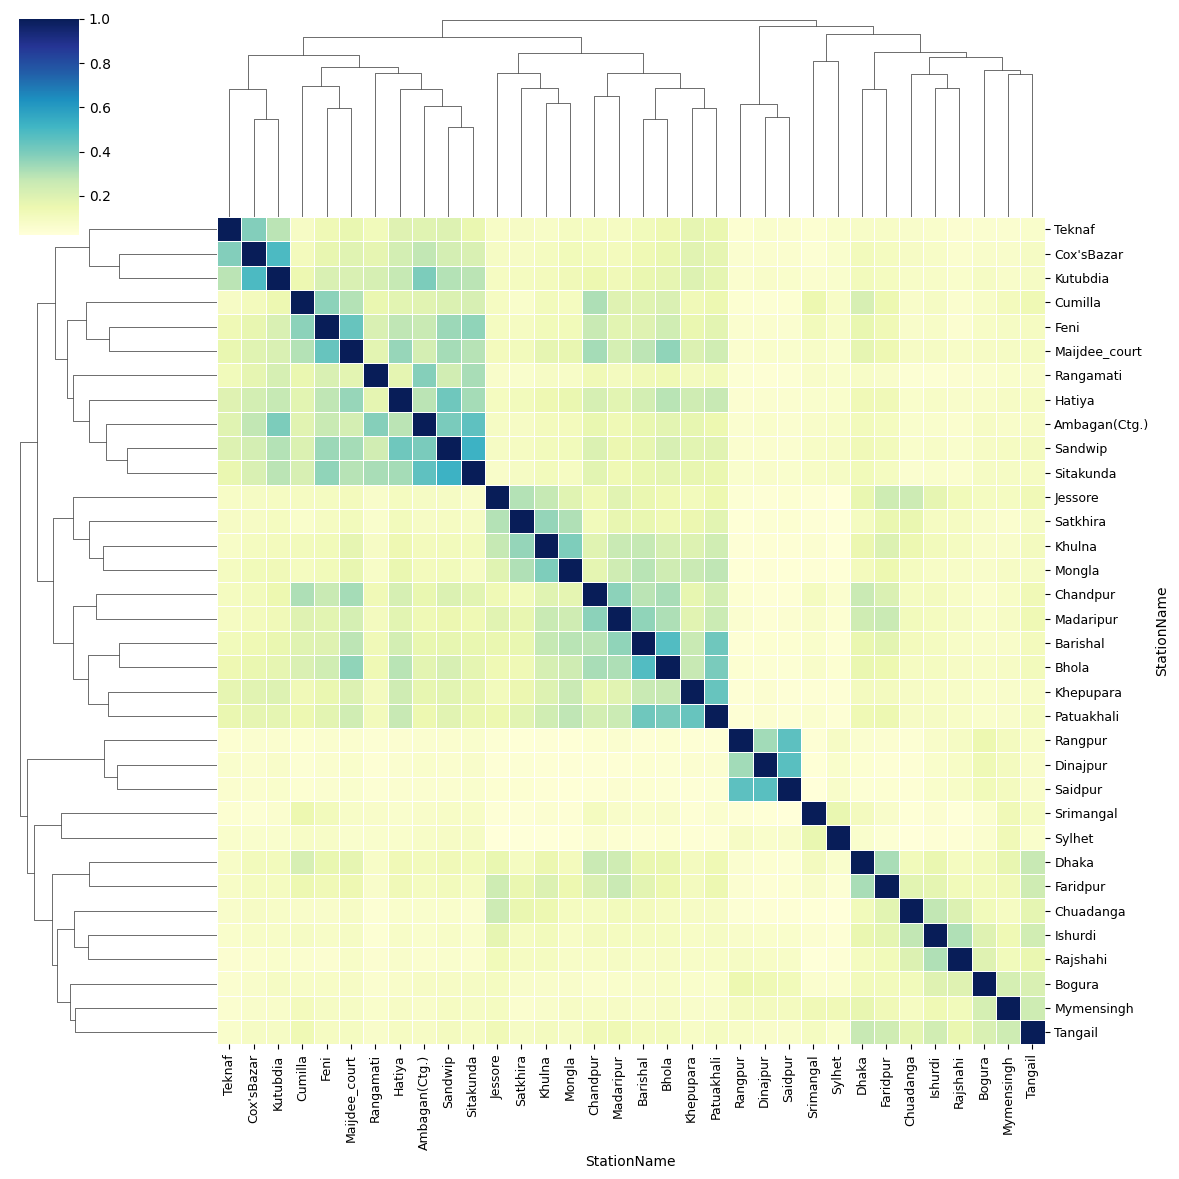

✅ Spatial Clustermap saved to /content/drive/MyDrive/Rainfall/EDA/Station_Spatial_Correlation.pdf


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Pivot the data: Rows = Time, Columns = Stations
# Using 'mean' handles potential duplicates if data is hourly/daily
df_pivot = df_rain.pivot_table(index='Datetime', columns='StationName', values='Rainfall', aggfunc='mean')

# 2. Calculate Pearson Correlation
# Dropping stations with all NaNs if any exist
corr_matrix = df_pivot.corr().dropna(how='all', axis=0).dropna(how='all', axis=1)

# 3. Plotting the Heatmap
# We use a Clustermap to show the hierarchical structure of station relationships
plt.figure(figsize=(12, 10))
g = sns.clustermap(corr_matrix,
                   annot=False,
                   cmap='YlGnBu',
                   linewidths=.5,
                   figsize=(12, 12),
                   cbar_pos=(0.02, 0.8, 0.05, 0.18))

# Adjust labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=9)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)

#plt.title("Spatial Correlation of Rainfall Between Stations (2003-2023)", fontsize=14, pad=60, fontweight='bold')

# Save the figure
save_path = "/content/drive/MyDrive/Rainfall/EDA/Station_Spatial_Correlation.pdf"
g.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Spatial Clustermap saved to {save_path}")

# **Precursor Analysis for Extreme Rainfall**

In [ ]:
import pandas as pd
import numpy as np

def create_extreme_precursor_dataset(df):
    df = df.sort_values(['StationName', 'Datetime']).reset_index(drop=True)

    def get_wet_95th(x):
        wet_data = x[x > 0.2]
        return np.nanpercentile(wet_data, 95) if len(wet_data) > 0 else np.nan

    df['thr95_wet'] = df.groupby('StationName')['Rainfall'].transform(get_wet_95th)

    feature_map = {
        'DewPointTemperature': 'Td',
        'Humidity': 'RH',
        'StationLevelPressure': 'P',
        'Rainfall': 'R',
        'SP': 'SP',
        'DR': 'DR'
    }

    for old_col, short_name in feature_map.items():
        if old_col not in df.columns:
            continue
        for step, hr in zip([1, 2, 3, 4], [3, 6, 9, 12]):
            df[f'{short_name}_{hr}h'] = df.groupby('StationName')[old_col].shift(step)

    df['Extreme'] = (df['Rainfall'] >= df['thr95_wet']).astype(int)

    df_extreme = df[df['Extreme'] == 1].copy()

    lag_cols = [c for c in df_extreme.columns if c.endswith(('3h','6h','9h','12h'))]
    before = len(df_extreme)
    df_extreme = df_extreme.dropna(subset=lag_cols)
    after = len(df_extreme)

    # Optional: drop raw met columns but KEEP Rainfall + thr95_wet for EDA
    cols_to_remove = [
        'Year', 'Month', 'Day', 'Time',
        'DewPointTemperature', 'StationLevelPressure', 'SP', 'DR', 'Humidity'
    ]
    df_extreme = df_extreme.drop(columns=cols_to_remove, errors='ignore')

    print(f"Extreme events before lag NaN drop: {before}, after: {after}, dropped: {before-after}")
    return df_extreme
df_extrem_final = create_extreme_precursor_dataset(df_rain)

Extreme events before lag NaN drop: 10737, after: 10737, dropped: 0


In [ ]:
df_extrem_final.columns

Index(['StationID', 'StationName', 'Latitude', 'Longitude', 'Primary_Region',
       'Secondary_Region', 'Datetime', 'Season', 'Rainfall', 'thr95_wet',
       'Td_3h', 'Td_6h', 'Td_9h', 'Td_12h', 'RH_3h', 'RH_6h', 'RH_9h',
       'RH_12h', 'P_3h', 'P_6h', 'P_9h', 'P_12h', 'R_3h', 'R_6h', 'R_9h',
       'R_12h', 'SP_3h', 'SP_6h', 'SP_9h', 'SP_12h', 'DR_3h', 'DR_6h', 'DR_9h',
       'DR_12h', 'Extreme'],
      dtype='object')

In [ ]:
df_extrem_final

,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Season,Rainfall,thr95_wet,...,R_12h,SP_3h,SP_6h,SP_9h,SP_12h,DR_3h,DR_6h,DR_9h,DR_12h,Extreme
719,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-03-31 21:00:00,Pre-Monsoon,91.0,32.2,...,1.0,2.0,2.0,0.0,0.0,18.0,18.0,0.0,0.0,1
1244,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-06-05 12:00:00,Monsoon,47.0,32.2,...,2.0,3.0,4.0,0.0,0.0,27.0,21.0,0.0,0.0,1
1281,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-06-10 03:00:00,Monsoon,65.0,32.2,...,1.0,2.0,2.0,2.0,2.0,18.0,18.0,18.0,18.0,1
1282,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-06-10 06:00:00,Monsoon,33.0,32.2,...,1.0,0.0,2.0,2.0,2.0,0.0,18.0,18.0,18.0,1
1290,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-06-11 06:00:00,Monsoon,34.0,32.2,...,0.0,2.0,3.0,2.0,2.0,13.0,13.0,18.0,18.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066608,11929,Teknaf,20.8667,92.3000,South East,Coastal,2022-06-19 15:00:00,Monsoon,39.0,34.0,...,3.8,0.0,0.0,1.0,2.0,0.0,0.0,23.0,16.0,1
2066619,11929,Teknaf,20.8667,92.3000,South East,Coastal,2022-06-21 00:00:00,Monsoon,50.0,34.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2067024,11929,Teknaf,20.8667,92.3000,South East,Coastal,2022-08-10 15:00:00,Monsoon,34.0,34.0,...,14.0,0.0,1.0,0.0,0.0,0.0,12.0,0.0,0.0,1
2067054,11929,Teknaf,20.8667,92.3000,South East,Coastal,2022-08-14 09:00:00,Monsoon,35.0,34.0,...,7.0,1.0,0.0,0.0,0.0,22.0,0.0,0.0,0.0,1


# **Composite precursor signatures preceding extreme rainfall events. Mean temporal evolution of (a) station-level pressure, (b) relative humidity, (c) dew point temperature, and (d) wind speed at 3, 6, 9, and 12 hours before extreme rainfall occurrences.**

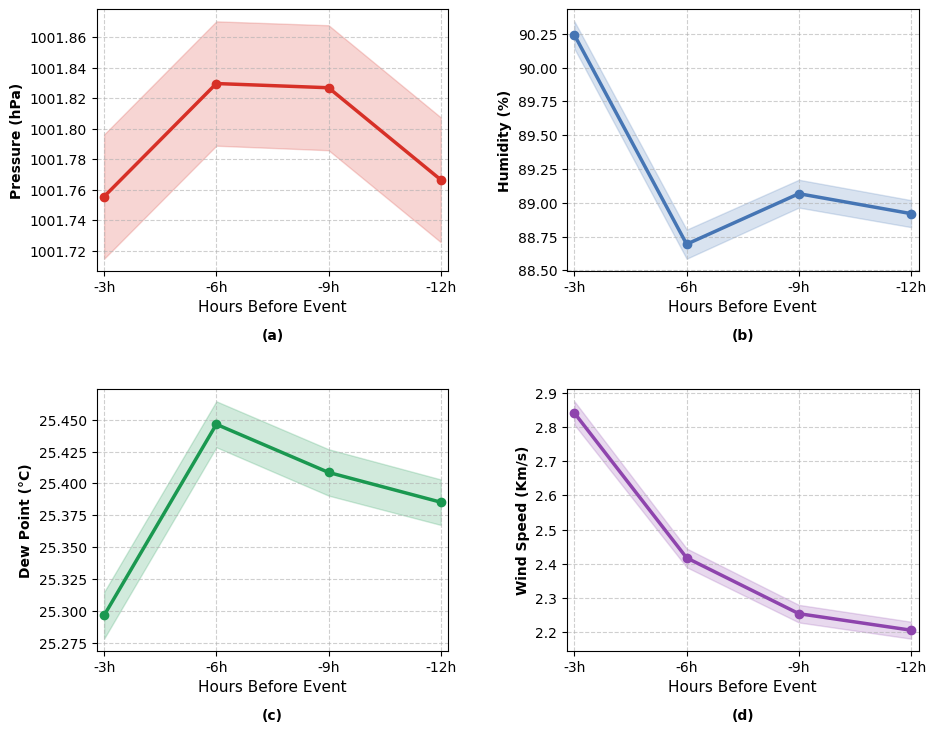

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter

def plot_extreme_signatures(df):
    # 1. Define the time steps (lags)
    lags = [3, 6, 9, 12]
    lag_labels = ['-3h', '-6h', '-9h', '-12h']

    # 2. Metrics dictionary
    metrics = {
        'P':  ['P_3h', 'P_6h', 'P_9h', 'P_12h'],
        'RH': ['RH_3h', 'RH_6h', 'RH_9h', 'RH_12h'],
        'Td': ['Td_3h', 'Td_6h', 'Td_9h', 'Td_12h'],
        'WS': ['SP_3h', 'SP_6h', 'SP_9h', 'SP_12h']
    }

    # Subplot labels
    sub_labels = ['(a)', '(b)', '(c)', '(d)']

    # Create 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    colors = ['#d73027', '#4575b4', '#1a9850', '#8e44ad']
    ylabels = ['Pressure (hPa)', 'Humidity (%)', 'Dew Point (°C)', 'Wind Speed (Km/s)']

    for i, (key, cols) in enumerate(metrics.items()):
        # Calculate stats
        means = df[cols].mean().values
        stds = df[cols].sem().values

        # Plot trend
        axes[i].plot(lags, means, marker='o', color=colors[i], linewidth=2.5)
        axes[i].fill_between(lags, means-stds, means+stds, color=colors[i], alpha=0.2)

        # Y-Axis Formatting
        axes[i].yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        axes[i].ticklabel_format(style='plain', axis='y')

        # X-Axis Formatting
        axes[i].set_xticks(lags)
        axes[i].set_xticklabels(lag_labels)
        axes[i].set_xlim(2.8, 12.2)

        # Labeling
        axes[i].set_ylabel(ylabels[i], fontsize=10, fontweight='bold')
        axes[i].set_xlabel("Hours Before Event", fontsize=11)
        axes[i].grid(True, linestyle='--', alpha=0.6)

        # Add (a), (b), (c), (d) at bottom middle of each subplot
        axes[i].text(0.5, -0.22, sub_labels[i], transform=axes[i].transAxes,
                     fontsize=10, fontweight='bold', ha='center', va='top')

    # Use tight_layout with padding to ensure labels don't overlap with the next row
    plt.tight_layout(pad=3.0)

    # Save and Show
    plt.savefig("/content/drive/MyDrive/Rainfall/EDA/Extreme_Event_Signatures.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# Run the analysis
plot_extreme_signatures(df_extrem_final)

**1. Composite precursor signatures preceding extreme rainfall events by primary climatic region, showing the mean evolution of (a) pressure, (b) relative humidity, (c) dew point temperature, and (d) wind speed at 3, 6, 9, and 12 hours before event onset.**

**2. Composite precursor signatures before extreme rainfall events for secondary regions (coastal, inland, and riverine), showing the mean evolution of (a) pressure, (b) relative humidity, (c) dew point temperature, and (d) wind speed at 3, 6, 9, and 12 hours prior to the event.**

**3. Composite precursor signatures of extreme rainfall events by season, showing the mean evolution of (a) pressure, (b) relative humidity, (c) dew point temperature, and (d) wind speed at 3, 6, 9, and 12 hours before the event.**

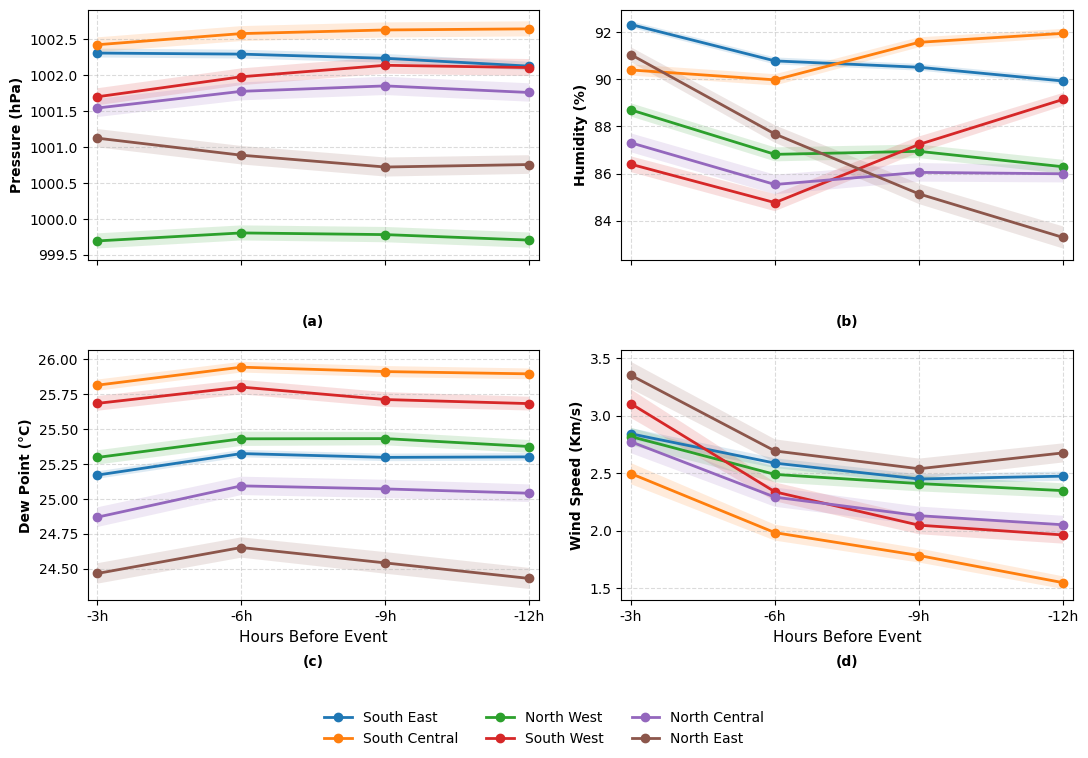

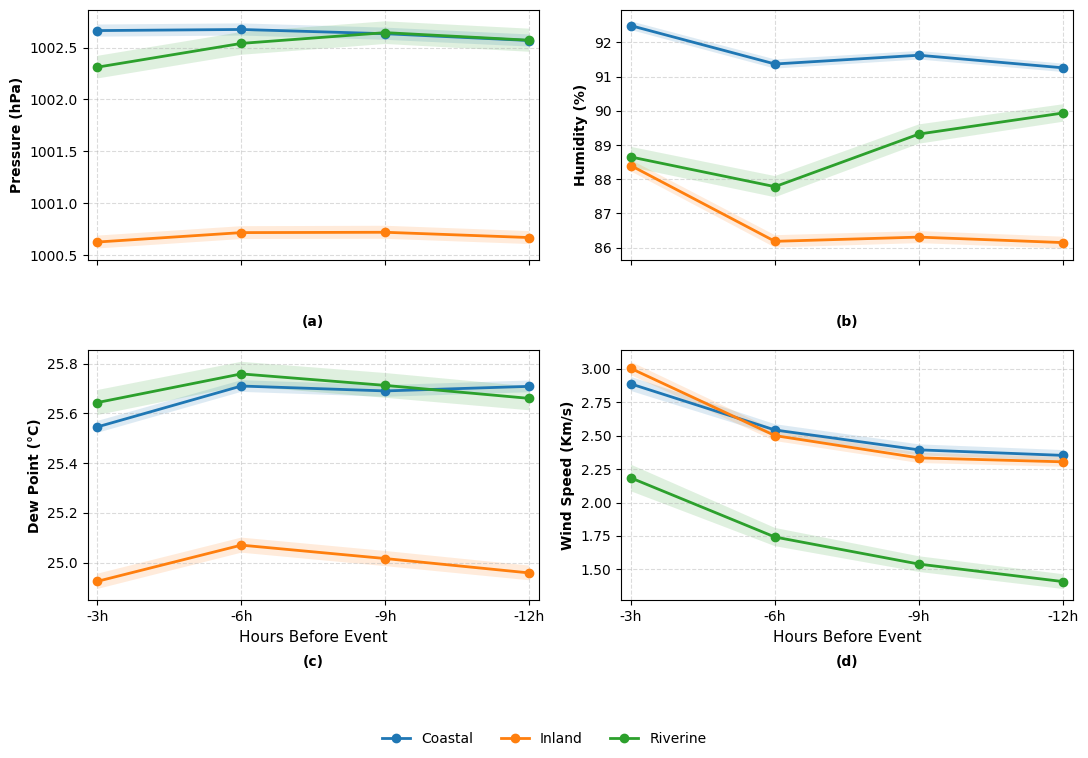

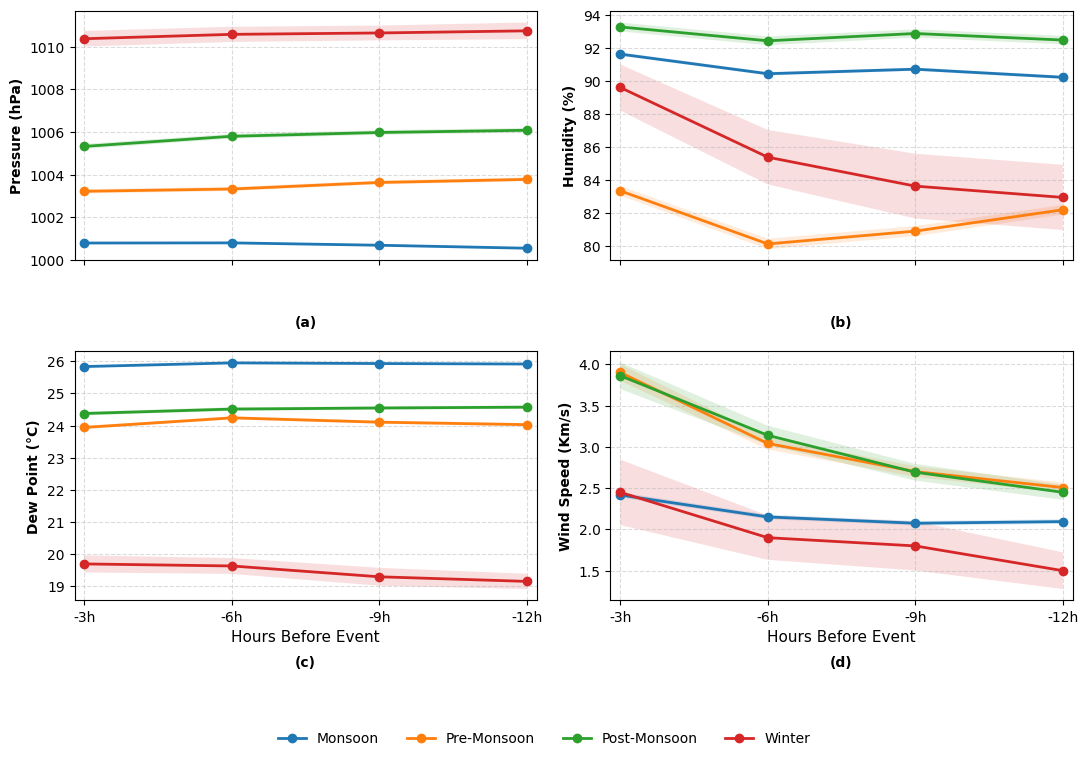

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def plot_signatures_by_group_2x2(
    df,
    group_col,
    save_path=None,
    min_group_size=30,
    max_groups=None,
    ncol_legend=4
):
    lags = [3, 6, 9, 12]
    lag_labels = ['-3h', '-6h', '-9h', '-12h']

    metrics = {
        'Pressure':  (['P_3h','P_6h','P_9h','P_12h'],   "Pressure (hPa)"),
        'Humidity':  (['RH_3h','RH_6h','RH_9h','RH_12h'], "Humidity (%)"),
        'Dew Point': (['Td_3h','Td_6h','Td_9h','Td_12h'], "Dew Point (°C)"),
        'Wind Speed':(['SP_3h','SP_6h','SP_9h','SP_12h'], "Wind Speed (Km/s)"),
    }

    sub_labels = ['(a)', '(b)', '(c)', '(d)']

    # Order groups by frequency (largest first)
    counts = df[group_col].value_counts()
    groups_order = counts.index.tolist()
    if max_groups is not None:
        groups_order = groups_order[:max_groups]

    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
    axes = axes.flatten()

    for i, (metric_name, (cols, ylabel)) in enumerate(metrics.items()):
        ax = axes[i]

        # plot each group as one line
        for g in groups_order:
            sub = df[df[group_col] == g]
            if len(sub) < min_group_size:
                continue

            means = sub[cols].mean().values
            sems  = sub[cols].sem().values  # shaded = ±SEM

            ax.plot(lags, means, marker='o', linewidth=2, label=str(g))
            ax.fill_between(lags, means - sems, means + sems, alpha=0.15)

        # x-axis
        ax.set_xticks(lags)
        ax.set_xticklabels(lag_labels)
        ax.set_xlim(2.8, 12.2)

        # y-axis formatting (nice for pressure)
        ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax.ticklabel_format(style='plain', axis='y')

        #ax.set_title(metric_name, fontsize=11, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=10,fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.45)

        ax.text(0.5, -0.22, sub_labels[i], transform=ax.transAxes,
                fontsize=10, fontweight='bold', ha='center', va='top')

    # common x label
    for ax in axes[2:]:
        ax.set_xlabel("Hours Before Event", fontsize=11)

    # one legend for the entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=ncol_legend, frameon=False)

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


# -----------------------------
# CALLS: 3 separate figures
# -----------------------------

# 1) Primary Region
plot_signatures_by_group_2x2(
    df_extrem_final,
    group_col="Primary_Region",
    #fig_title="Extreme Event Precursor Signatures by Primary Climatic Region",
    save_path="/content/drive/MyDrive/Rainfall/EDA/Signatures_By_PrimaryRegion.pdf",
    ncol_legend=3
)

# 2) Secondary Region
plot_signatures_by_group_2x2(
    df_extrem_final,
    group_col="Secondary_Region",
    #fig_title="Extreme Event Precursor Signatures by Physiographic Region (Secondary)",
    save_path="/content/drive/MyDrive/Rainfall/EDA/Signatures_By_SecondaryRegion.pdf",
    ncol_legend=3
)

# 3) Season
plot_signatures_by_group_2x2(
    df_extrem_final,
    group_col="Season",
    #fig_title="Extreme Event Precursor Signatures by Season",
    save_path="/content/drive/MyDrive/Rainfall/EDA/Signatures_By_Season.pdf",
    ncol_legend=4
)


# Model Figure

In [10]:
pip install torchviz torchview graphviz

In [11]:
import torch
from torchviz import make_dot
from torchview import draw_graph

# 1. Exact Dimensions from BanglaRain-ENS (Trial 4 & Dataset)
B = 16            # Batch size (Trial 4)
T_in = 24         # Input window (Trial 4: 24 steps = 72 hours)
N = 34            # Number of stations (BMD Dataset)
F_in = 18         # Input features (7 weather + 7 masks + 4 time cyclical)
num_seasons = 4   # Regimes (Winter, Pre-monsoon, Monsoon, Post-monsoon)
H_out = 8         # Forecast Horizon (8 steps = 24 hours)
k_nn = 7          # Spatial graph connectivity (Trial 4)
E = N * k_nn      # Exact number of directed edges (34 * 7 = 238)

# 2. Initialize the Model with Exact Trial 4 Hyperparameters
# Assumes BanglaRainENS class is already defined in your environment
model = BanglaRainENS(
    num_stations=N,
    in_features=F_in,
    T_in=T_in,
    H_out=H_out,
    num_seasons=num_seasons,
    quantiles=(0.1, 0.5, 0.9),
    d_model=64,                   # Trial 4
    n_heads=8,                    # Trial 4
    num_temporal_layers=2,        # Trial 4
    num_gat_layers=2,             # Trial 4
    gat_heads=2,                  # Trial 4
    dropout=0.20,                 # Trial 4
)

# 3. Create Exact Dummy Input Data Tensors
x_exact = torch.randn(B, T_in, N, F_in)
reg_exact = torch.randint(0, num_seasons, (B,))
edge_index_exact = torch.randint(0, N, (2, E))

# =====================================================================
# OPTION A: Using Torchview (Clean, hierarchical module boxes)
# =====================================================================
print("Generating Torchview diagram...")

model_graph = draw_graph(
    model,
    input_data=(x_exact, reg_exact, edge_index_exact),
    graph_name="BanglaRainENS_Exact_Architecture",
    expand_nested=True,
    save_graph=True,
    filename="BanglaRainENS_Architecture_Torchview"
)

# =====================================================================
# OPTION B: Using Torchviz (Detailed execution/gradient graph)
# =====================================================================
print("Generating Torchviz diagram...")

# Forward pass to trace the exact graph
q, flash_logits, peak_logits, acc_logits = model(x_exact, reg_exact, edge_index_exact)

dot = make_dot(
    {"Quantiles (24)": q, "Flash Flood (1)": flash_logits, "Peak (1)": peak_logits, "Accumulation (1)": acc_logits},
    params=dict(model.named_parameters()),
    show_attrs=True,       # Shows tensor shapes (e.g., 16x24x34x18)
    show_saved=True
)

dot.format = 'png'
dot.render("BanglaRainENS_Architecture_Torchviz")
print("Diagrams saved successfully!")

NameError: name 'BanglaRainENS' is not defined